<a href="https://colab.research.google.com/github/Awimya-Rn/PCVK26_13_Ilham/blob/main/week6_13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PRAKTIKUM FILTER

## Cell Identitas

In [1]:
NAMA = 'Mokhammad Ilham Putra Wijaya'
NIM = '244107020139'
print(NAMA, NIM)

Mokhammad Ilham Putra Wijaya 244107020139


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im

## fungsi konvolusi

In [4]:
def convolution2d(image, kernel, stride, padding):
  if padding > 0:
    padded_image = np.pad(image, pad_width=padding, mode='constant', constant_values=0)
  else:
    padded_image = image

  img_h, img_w = padded_image.shape
  kh, kw = kernel.shape

  out_h = int((image.shape[0] - kh + 2 * padding) / stride) + 1
  out_w = int((image.shape[1] - kw + 2 * padding) / stride) + 1

  output = np.zeros((out_h, out_w), dtype=np.float32)
  for i in range(out_h):
    for j in range(out_w):
      start_i = i * stride
      end_i = start_i + kh
      start_j = j * stride
      end_j = start_j + kw
      region = padded_image[start_i:end_i, start_j:end_j]
      output[i, j] = np.sum(region*kernel)

  return output

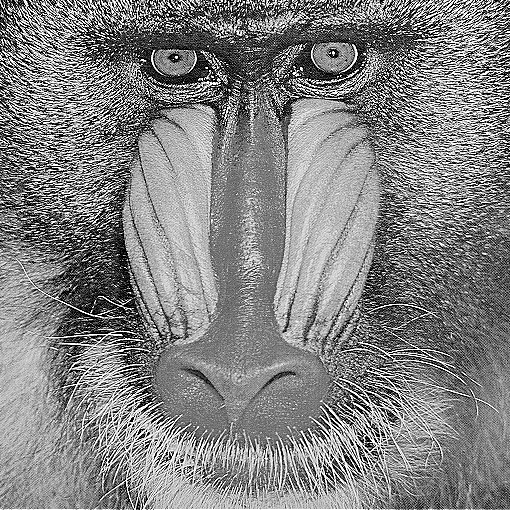

In [5]:
img = cv.imread('/content/drive/MyDrive/PCVK/Images/244107020139/mandrill.tiff')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
kernel_sharpen = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]])
img_sharpen = convolution2d(img_gray, kernel_sharpen, 1, 0)
cv2_imshow(img_sharpen)

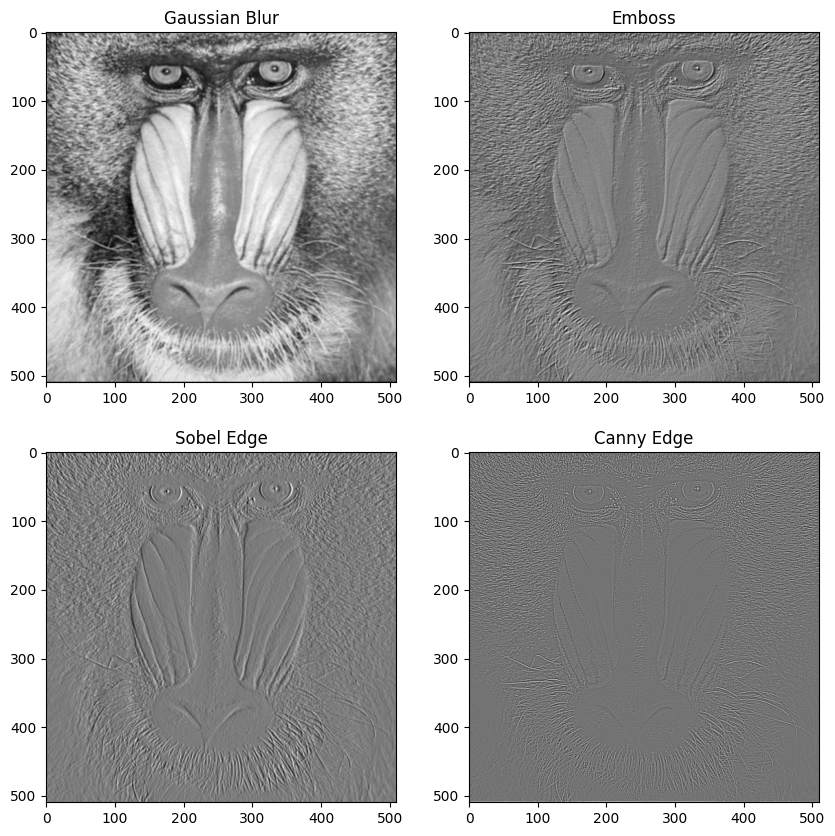

In [6]:
kernel_emboss = np.array([[-2,-1,0],[-1,1,1],[0,1,2]])
kernel_sobel_edge = np.array([[1,0,-1],[2,0,-2],[1,0,-1]])
kernel_canny_edge = np.array([[-1,-1,-1],[-1,8,-1],[-1,-1,-1]])

img_emboss = convolution2d(img_gray, kernel_emboss, 1, 0)
img_sobel_edge = convolution2d(img_gray, kernel_sobel_edge, 1, 0)
img_canny_edge = convolution2d(img_gray, kernel_canny_edge, 1, 0)

sigma=math.sqrt(3)
gaussian_kernel = cv.getGaussianKernel(3, sigma)
gaussian_kernel = gaussian_kernel @ gaussian_kernel.transpose()
img_gaussian = convolution2d(img_gray, gaussian_kernel, 1, 0)

fig, ax = plt.subplots(2,2, figsize=(10,10))
ax[0,0].imshow(img_gaussian, cmap='gray')
ax[0,0].set_title('Gaussian Blur')
ax[0,1].imshow(img_emboss, cmap='gray')
ax[0,1].set_title('Emboss')
ax[1,0].imshow(img_sobel_edge, cmap='gray')
ax[1,0].set_title('Sobel Edge')
ax[1,1].imshow(img_canny_edge, cmap='gray')
ax[1,1].set_title('Canny Edge')
plt.show()

# FILTER LIBRARY DAN FILTER MODERN

## Percobaan 1

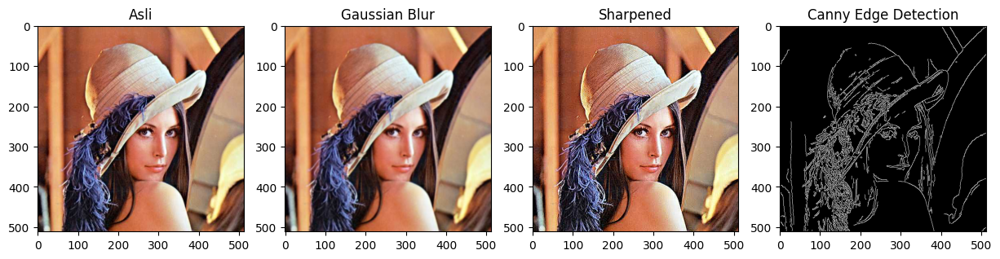

In [7]:
def show_side_by_side(images, titles, figsize=(15,5)):
  plt.figure(figsize=figsize)
  for i, (img, title) in enumerate(zip(images, titles)):
    if len(img.shape) == 2:
      plt.subplot(1, len(images), i+1)
      plt.imshow(img, cmap='gray')
    else:
      plt.subplot(1, len(images), i+1)
      plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    plt.title(title)
  plt.show()

img = cv.imread('/content/drive/MyDrive/PCVK/Images/244107020139/lena.jpg')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

blur = cv.GaussianBlur(img, (7,7), 1)
edges = cv.Canny(img_gray, 100, 200)
sharpened = cv.filter2D(img, -1, kernel_sharpen)
show_side_by_side([img, blur, sharpened, edges], ['Asli', 'Gaussian Blur', 'Sharpened', 'Canny Edge Detection'])

## Percobaan 2

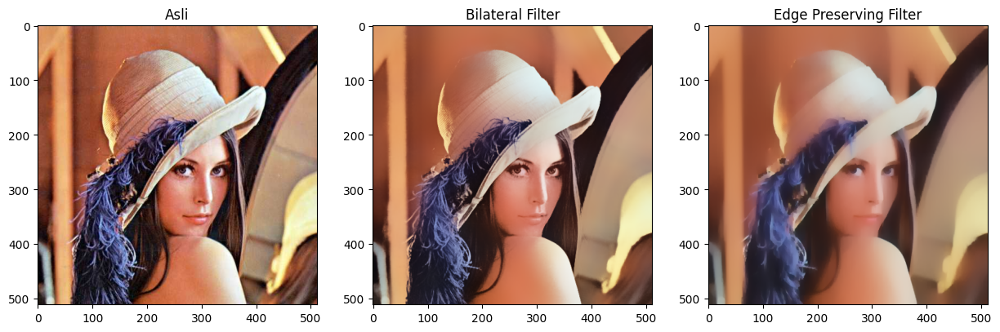

In [8]:
bilateral = cv.bilateralFilter(img, 50, 100, 100)

edge_preserve = cv.edgePreservingFilter(img, flags=1, sigma_s=100, sigma_r=0.9)
show_side_by_side([img, bilateral, edge_preserve], ['Asli', 'Bilateral Filter', 'Edge Preserving Filter'])

## Percobaan 3

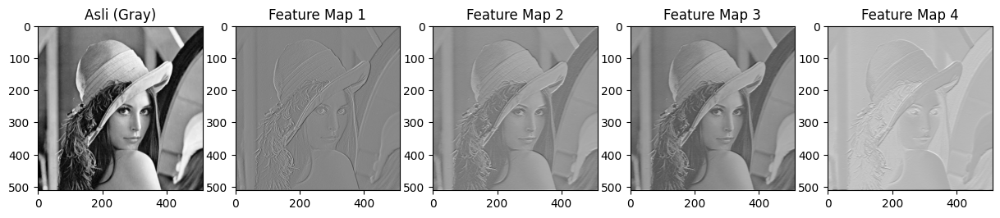

In [11]:
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
  def __init__(self):
    super(SimpleCNN, self).__init__()
    self.conv1 = nn.Conv2d(1, 4, kernel_size=3, padding=1)

  def forward(self, x):
    return self.conv1(x)

model = SimpleCNN()

img_tensor = torch.tensor(img_gray, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0

with torch.no_grad():
  features = model(img_tensor)

feature_maps = [features[0,i].numpy() for i in range(features.shape[1])]
show_side_by_side([img_gray] + feature_maps, ["Asli (Gray)"] + [f'Feature Map {i+1}' for i in range(len(feature_maps))])

## Percobaan 4

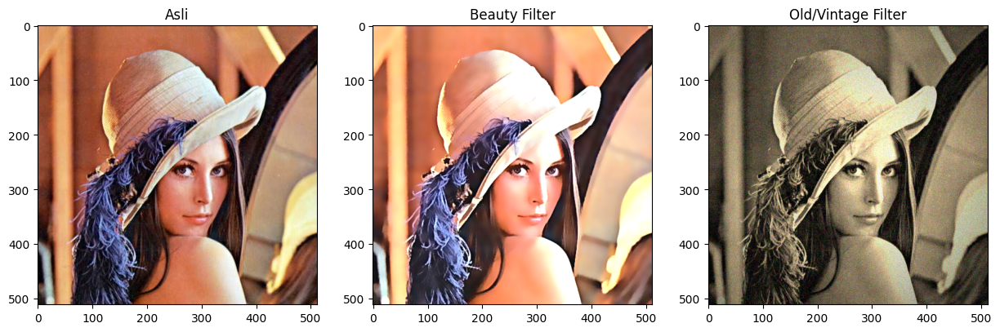

In [12]:
smooth = cv.bilateralFilter(img, d=15, sigmaColor=75, sigmaSpace=75)

gaussian = cv.GaussianBlur(smooth, (0,0), 3)
sharpened = cv.addWeighted(smooth, 1.5, gaussian, -0.5, 0)

alpha = 1.2
beta = 15
beauty = cv.convertScaleAbs(sharpened, alpha=alpha, beta=beta)

sepia_kernel = np.array([[0.272, 0.534, 0.131], [0.349, 0.686, 0.168], [0.393, 0.769, 0.189]])
sepia = cv.transform(img, sepia_kernel)
sepia = np.clip(sepia, 0, 255).astype(np.uint8)

rows, cols = img.shape[:2]
kernel_x = cv.getGaussianKernel(cols, cols*0.6)
kernel_y = cv.getGaussianKernel(rows, rows*0.6)
kernel = kernel_y * kernel_x.T
mask = kernel / kernel.max()
vignette = np.copy(sepia)
for i in range(3):
  vignette[:,:,i] = vignette[:,:,i] * mask

noise = np.random.normal(0, 15, vignette.shape).astype(np.int16)
old_img = np.clip(vignette.astype(np.int16) + noise, 0, 255).astype(np.uint8)
show_side_by_side([img, beauty, old_img], ['Asli', 'Beauty Filter', 'Old/Vintage Filter'])

## Percobaan 5

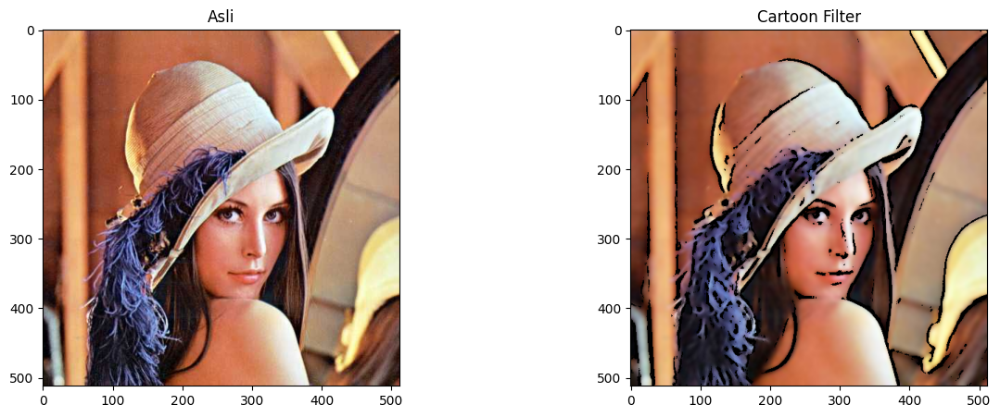

In [13]:
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gray_blur = cv.medianBlur(gray, 7)
edges = cv.adaptiveThreshold(gray_blur, 255, cv.ADAPTIVE_THRESH_MEAN_C, cv.THRESH_BINARY, 9,9)

color = cv.bilateralFilter(img, d=9, sigmaColor=200, sigmaSpace=200)

cartoon = cv.bitwise_and(color, color, mask=edges)

show_side_by_side([img, cartoon], ['Asli', 'Cartoon Filter'])

## Percobaan 6

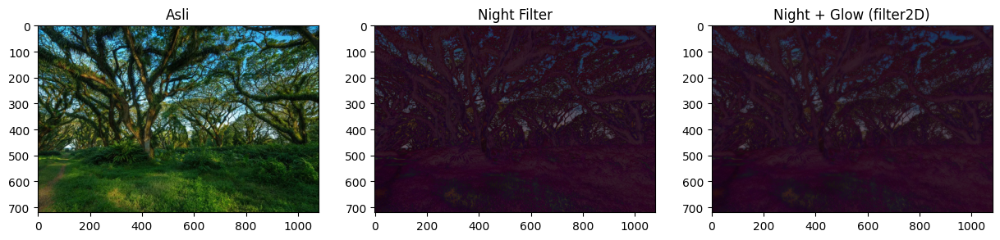

In [14]:
img = cv.imread('/content/drive/MyDrive/PCVK/Images/244107020139/djawatan.jpg')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

night = cv.convertScaleAbs(img, alpha=0.6, beta=-40)

blue_tint = np.full_like(night, (50,0,100))
night = cv.addWeighted(night, 0.8, blue_tint, 0.2, 0)

kernel = np.ones((15,15), np.float32) / 225
glow = cv.filter2D(night, -1, kernel)

night_glow = cv.addWeighted(night, 0.7, glow, 0.3, 0)

show_side_by_side([img, night, night_glow], ['Asli', 'Night Filter', 'Night + Glow (filter2D)'])

## Percobaan 7

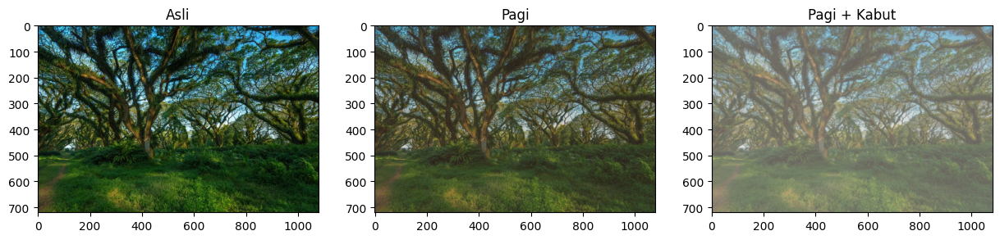

In [15]:
alpha = 0.9
beta = 20
soft = cv.convertScaleAbs(img, alpha=alpha, beta=beta)

warm_tint = np.full_like(soft, (40,70,120))
pagi = cv.addWeighted(soft, 0.8, warm_tint, 0.2, 0)

kernel = cv.getGaussianKernel(3,3)
kernel = kernel @ kernel.T
kabut = cv.filter2D(pagi, -1, kernel)

white_layer = np.full_like(pagi, 255)
kabut = cv.addWeighted(kabut, 0.7, white_layer, 0.3, 0)

show_side_by_side([img, pagi, kabut], ["Asli", "Pagi", "Pagi + Kabut"])

# 1. Tugas Analisis: Perbandingan Mean Filter (Blur Biasa) vs. Median Filter pada Noise “Salt and Pepper”

## a. Tambah noise

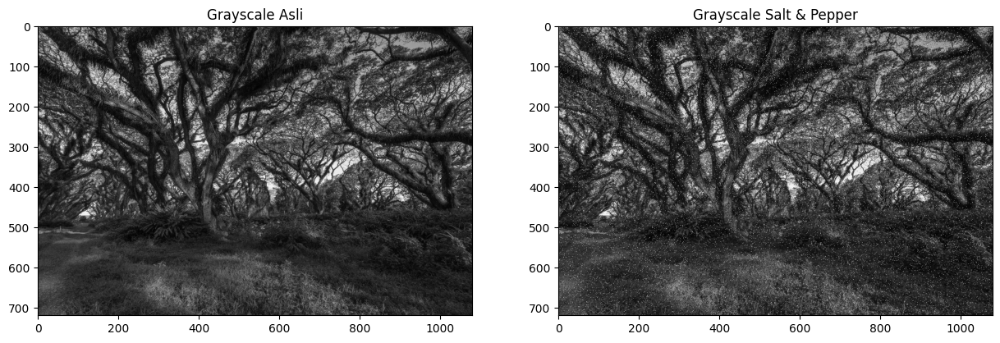

In [16]:
amount = 0.05
salt_ratio = 0.5
seed = 42

rng = np.random.default_rng()
img_sp = img_gray.copy()
rnd = rng.random(img_gray.shape)
img_sp[rnd < amount * salt_ratio] = 255
img_sp[(rnd >= amount * salt_ratio) & (rnd < amount)] = 0

show_side_by_side([img_gray, img_sp], ["Grayscale Asli", "Grayscale Salt & Pepper"])

## b. Mean Filter 3x3 dan Median Filter 3x3

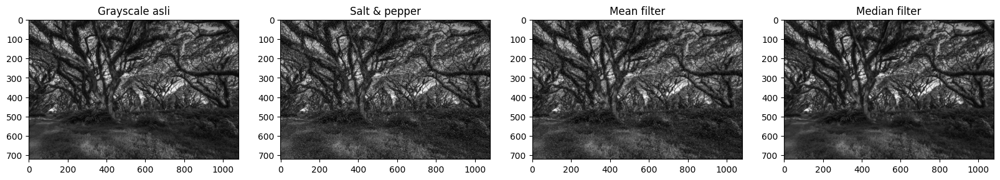

In [17]:
from numpy.lib.stride_tricks import sliding_window_view

kernel_mean = np.ones((3,3))/9
mean_result = np.clip(convolution2d(img_sp, kernel_mean, stride=1, padding=1))

ksize = 3
pad = ksize // 2
padded = np.pad(img_sp, pad, mode='edge')
windows = sliding_window_view(padded, (ksize, ksize))
median_result = np.median(windows, axis=(2,3)).astype(np.uint8)

show_side_by_side([img_gray, img_sp, mean_result, median_result], ["Grayscale asli", "Salt & pepper", "Mean filter", "Median filter"], figsize=(20,5))


## c. Analisis: metrik dan zoom
- Mean Filter mengganti piksel dengan rata-rata tetangga. Piksel noise (0 atau 255) ikut masuk ke rata-rata, sehingga nilainya hanya menyebar ke sekitarnya. Noise tidak hilang, berubah menjadi bercak abu-abu, dan citra menjadi blur (tepi ikut kabur).
- Median Filter mengganti piksel dengan nilai tengah dari 9 tetangga yang diurutkan. Nilai ekstrem (0/255) selalu berada di ujung urutan sehingga tidak terpilih. Noise benar-benar dibuang, bukan dirata-rata.
- Median juga lebih menjaga tepi karena nilai yang dipilih adalah nilai asli di jendela.

# 2. Tugas Evaluasi: Pemilihan Ukuran Kernel terbaik untuk Menajamkan Citra (Sharpening)

## a. Buat kernel penajaman (Sharpening Kernel) ukuran 3 x 3 dan 5 x 5.


In [18]:
kernel_sharp_3 = np.array([[ 0,-1, 0],
                           [-1, 5,-1],
                           [ 0,-1, 0]], dtype=np.float64)

kernel_sharp_5 = (1/8.0) * np.array([[-1,-1,-1,-1,-1],
                                     [-1, 2, 2, 2,-1],
                                     [-1, 2, 8, 2,-1],
                                     [-1, 2, 2, 2,-1],
                                     [-1,-1,-1,-1,-1]], dtype=np.float64)

print("Jumlah kernel 3x3 :", kernel_sharp_3.sum())
print("Jumlah kernel 5x5 :", kernel_sharp_5.sum())

Jumlah kernel 3x3 : 1.0
Jumlah kernel 5x5 : 1.0


## b. Terapkan pada citra yang sedikit buram (blurry).

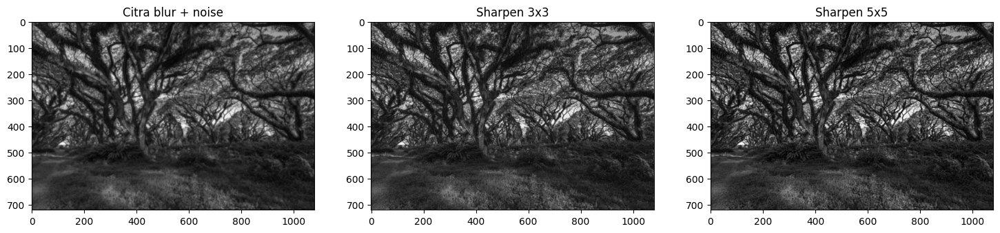

In [19]:
blurry = cv.GaussianBlur(img_gray, (5,5), 1.5)
rng = np.random.default_rng(0)
noise = rng.normal(0, 4, blurry.shape)
blurry_noisy = np.clip(blurry + noise, 0, 255).astype(np.uint8)

sharp3_clean = convolution2d(blurry, kernel_sharp_3, 1, 1)
sharp5_clean = convolution2d(blurry, kernel_sharp_5, 1, 2)
sharp3_noisy = convolution2d(blurry_noisy, kernel_sharp_3, 1, 1)
sharp5_noisy = convolution2d(blurry_noisy, kernel_sharp_5, 1, 2)

blurry_sharp3_noisy = np.clip(sharp3_noisy, 0, 255).astype(np.uint8)
blurry_sharp5_noisy = np.clip(sharp5_noisy, 0, 255).astype(np.uint8)

show_side_by_side([blurry_noisy, blurry_sharp3_noisy, blurry_sharp5_noisy], ["Citra blur + noise", "Sharpen 3x3", "Sharpen 5x5"], figsize=(18,6))


## c. Evaluasi hasilnya berdasarkan aspek Kejelasan Tepi vs. Kadar Noise/Noise Distortion yang dihasilkan. Tentukan kernel mana yang paling optimal untuk digunakan sehari-hari.

Citra                 Kejelasan Tepi  Noise (std)   Tepi x  Noise x  Tepi/Noise
Buram (referensi)              69.68         4.00     1.00     1.00        1.00
Sharpen 3x3                   513.02        21.62     7.36     5.40        1.36
Sharpen 5x5                   237.66         5.30     3.41     1.32        2.58


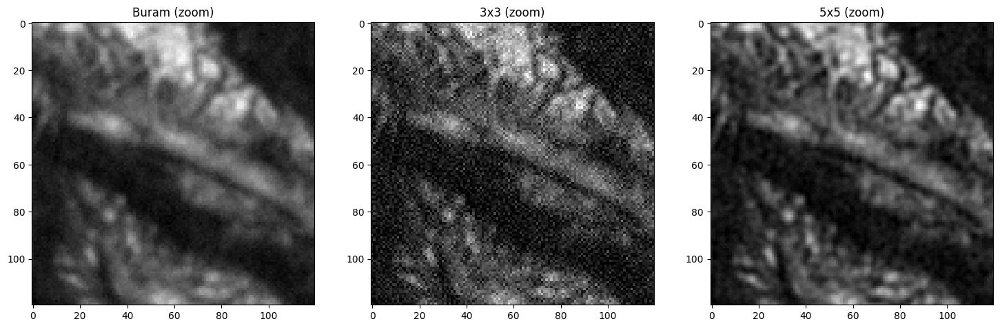

In [20]:
lap = np.array([[0,1,0],[1,-4,1],[0,1,0]])

def edge_sharpness(image):
  return convolution2d(image, lap, 1, 1).var()

def noise_amplification(sharp_noisy, sharp_clean):
  return np.std(sharp_noisy - sharp_clean)

ref_sharp = edge_sharpness(blurry.astype(float))
ref_noise = np.std(noise)
s3, n3 = edge_sharpness(sharp3_clean), noise_amplification(sharp3_noisy, sharp3_clean)
s5, n5 = edge_sharpness(sharp5_clean), noise_amplification(sharp5_noisy, sharp5_clean)

print(f"{'Citra':20s} {'Kejelasan Tepi':>15s} {'Noise (std)':>12s} {'Tepi x':>8s} {'Noise x':>8s} {'Tepi/Noise':>11s}")
print(f"{'Buram (referensi)':20s} {ref_sharp:15.2f} {ref_noise:12.2f} {1:8.2f} {1:8.2f} {1:11.2f}")
print(f"{'Sharpen 3x3':20s} {s3:15.2f} {n3:12.2f} {s3/ref_sharp:8.2f} {n3/ref_noise:8.2f} {(s3/ref_sharp)/(n3/ref_noise):11.2f}")
print(f"{'Sharpen 5x5':20s} {s5:15.2f} {n5:12.2f} {s5/ref_sharp:8.2f} {n5/ref_noise:8.2f} {(s5/ref_sharp)/(n5/ref_noise):11.2f}")

y0, x0, s = 150, 150, 120
crops = [c[y0:y0+s, x0:x0+s] for c in (blurry_noisy, blurry_sharp3_noisy, blurry_sharp5_noisy)]
show_side_by_side(crops, ["Buram (zoom)", "3x3 (zoom)", "5x5 (zoom)"], figsize=(18,6))

Analisis Tugas 2
- Kernel 3x3: tepi sangat tajam, detail halus langsung terlihat, tetapi noise ikut diperkuat banyak dan bisa muncul halo tipis di tepi kontras tinggi. Komputasi 9 perkalian per piksel.
- Kernel 5x5: penajaman lebih lembut, noise diperkuat jauh lebih sedikit sehingga hasil lebih bersih, tetapi efek penajamannya lebih lemah. Komputasi 25 perkalian per piksel (lebih lambat).


# 3. Tugas Kreasi: Filter Kartun Sederhana

## a. Buatlah sebuah fungsi kustom bernama kartun(image) yang menggabungkan:
* Penghalusan warna menggunakan **Bilateral Filter** agar area warna menjadi rata.
* Deteksi garis tepi menggunakan **Adaptive Thresholding** atau **Canny Edge**.
* Penggabungan (kombinasi) keduanya menggunakan operasi logika/perkalian piksel

In [21]:
def kartun(image, metode_tepi="adaptive"):
  color = image.copy()
  for _ in range(2):
    color = cv.bilateralFilter(color, d=9, sigmaColor=200, sigmaSpace=200)

  gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
  gray_blur = cv.medianBlur(gray, 7)

  if metode_tepi == "canny":
    edges = cv.Canny(gray_blur, 100, 200)
    edges = cv.bitwise_not(edges)
  else:
    edges = cv.adaptiveThreshold(gray_blur, 255, cv.ADAPTIVE_THRESH_MEAN_C, cv.THRESH_BINARY, 9, 9)

  hasil = cv.bitwise_and(color, color, mask=edges)
  return hasil

## b. Tampilkan hasil citra asli dengan citra efek kartun bersebelahan.

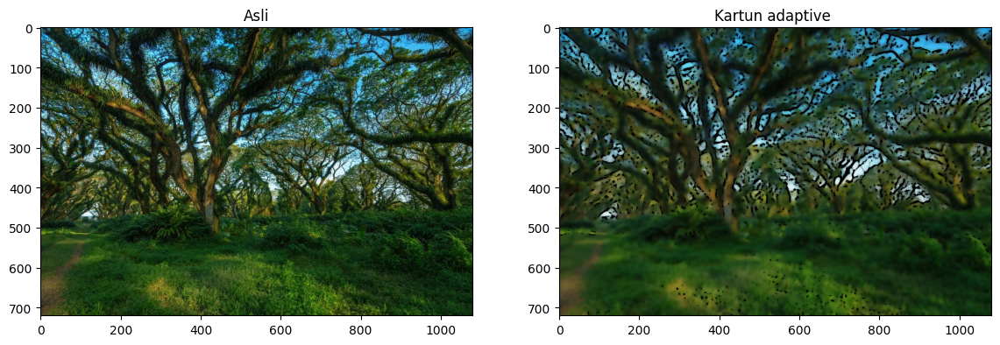

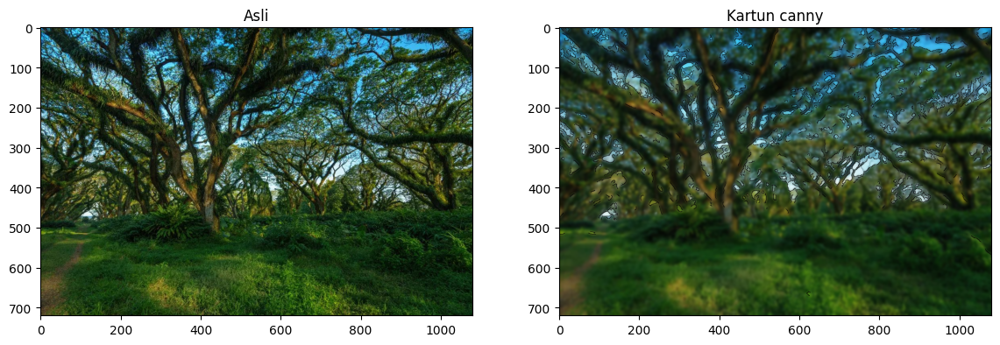

In [22]:
cartoon_adaptive = kartun(img, "adaptive")
cartoon_canny = kartun(img, "canny")

show_side_by_side([img, cartoon_adaptive], ["Asli", "Kartun adaptive "], figsize=(14,7))
show_side_by_side([img, cartoon_canny], ["Asli", "Kartun canny"], figsize=(14,7))